# Fiqah Question Answering System
### RAG-based Islamic Q&A using Quran, Hadees, and Mufti Usmani Tafseer

This system retrieves relevant Quran ayaat and Ahadees for any Fiqah question,
shows them with proper references and Urdu translation, and summarizes only from
retrieved text. No AI-generated rulings are ever produced.

In [ ]:
# sentence-transformers: loads the multilingual-e5-large embedding model
# used to convert Urdu and English text into vectors for semantic search
!pip install sentence-transformers

# chromadb: vector database that stores and searches our embeddings
# this is where all Quran ayaat and Ahadees are indexed
!pip install chromadb

# gradio: builds the user interface
# users type their question and see results in a clean web interface
!pip install gradio

# anthropic: connects to Claude API for the final summarization step
# Claude reads only the retrieved texts and summarizes what they say
!pip install anthropic

# requests: makes HTTP calls to Quran and Hadees APIs
# used to fetch ayaat from quranenc and Ahadees from sunnah.com
!pip install requests

# pymupdf: reads PDF files
# used to extract text from the Mufti Usmani Qurbani chapter PDF
!pip install pymupdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling opentele

## Step 2 — Mount Google Drive

All processed data, vector databases, and saved files will be stored in Google Drive.
This ensures that even if the Colab session disconnects, no work is lost.
Every file we create from this point will be saved under:

My Drive > FiqahQA > (subfolders for data, vectorstore, models)

In [ ]:
from google.colab import drive

# mount Google Drive so we can read and write files permanently
drive.mount('/content/drive', force_remount=True)

import os

# define the main project folder path
BASE_DIR = '/content/drive/MyDrive/FiqahQA'

# create subfolders for each type of data
os.makedirs(f'{BASE_DIR}/data/quran',      exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/hadees',     exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/tafseer',    exist_ok=True)
os.makedirs(f'{BASE_DIR}/vectorstore',     exist_ok=True)

print("Google Drive mounted successfully.")
print("Project folders created at:", BASE_DIR)
print()
print("Folder structure:")
for folder in ['data/quran', 'data/hadees', 'data/tafseer', 'vectorstore']:
    print(f"  FiqahQA/{folder}")

ValueError: Mountpoint must not already contain files

In [ ]:
from google.colab import drive
import os

# Drive is already mounted — skip remount
# Just verify it is accessible
BASE_DIR = '/content/drive/MyDrive/FiqahQA'

os.makedirs(f'{BASE_DIR}/data/quran',   exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/hadees',  exist_ok=True)
os.makedirs(f'{BASE_DIR}/data/tafseer', exist_ok=True)
os.makedirs(f'{BASE_DIR}/vectorstore',  exist_ok=True)

print("Drive already mounted. Folders verified.")
print("Base directory:", BASE_DIR)

Drive already mounted. Folders verified.
Base directory: /content/drive/MyDrive/FiqahQA


## Step 3 — Download Quran Data

We use two sources:
- Arabic text from alquran.cloud API (reliable, structured, ayah by ayah)
- Urdu translation by Mufti Taqi Usmani from his "Aasan Tarjuma Quran" PDF

The PDF will be processed in a later step when we handle all PDF extraction together.
For now we download and save the Arabic text with surah and ayah references.

UTF-8 covers the entire Unicode standard
Arabic characters sit in the Unicode range U+0600 – U+06FF. UTF-8 can encode every Unicode character, so all Arabic letters, diacritics (tashkeel like fatha ـَ, kasra ـِ), and Quranic symbols are handled correctly.
With indent=2
pythonjson.dump(data, f, indent=2)
Each key gets its own line, indented by 2 spaces:

In [ ]:
import requests
import json
import os

BASE_DIR = '/content/drive/MyDrive/FiqahQA'
arabic_path = f'{BASE_DIR}/data/quran/quran_arabic.json'

if not os.path.exists(arabic_path):
    print("Downloading Arabic Quran text...")

    # fetch all 6236 ayaat with surah and ayah numbers
    response = requests.get('http://api.alquran.cloud/v1/quran/quran-simple')

    if response.status_code == 200:
        raw = response.json()

        quran_data = []

        for surah in raw['data']['surahs']:
            surah_number = surah['number']
            surah_name   = surah['name']           # Arabic name
            surah_english = surah['englishName']   # English name

            for ayah in surah['ayahs']:
                quran_data.append({
                    'surah_number'  : surah_number,
                    'surah_name'    : surah_name,
                    'surah_english' : surah_english,
                    'ayah_number'   : ayah['numberInSurah'],
                    'arabic_text'   : ayah['text'],
                    'reference'     : f"Surah {surah_english} ({surah_number}:{ayah['numberInSurah']})"
                })

        with open(arabic_path, 'w', encoding='utf-8') as f:
            json.dump(quran_data, f, ensure_ascii=False, indent=2)

        print(f"Downloaded and saved {len(quran_data)} ayaat.")
        print(f"Saved to: {arabic_path}")

    else:
        print(f"API call failed. Status code: {response.status_code}")

else:
    print("Arabic Quran data already exists on Drive. Skipping download.")

    with open(arabic_path, 'r', encoding='utf-8') as f:
        quran_data = json.load(f)

    print(f"Loaded {len(quran_data)} ayaat from Drive.")

# quick check — print first 2 entries to confirm structure
print()
print("Sample entry:")
print(json.dumps(quran_data[0], ensure_ascii=False, indent=2))

Arabic Quran data already exists on Drive. Skipping download.
Loaded 6236 ayaat from Drive.

Sample entry:
{
  "surah_number": 1,
  "surah_name": "سُورَةُ ٱلْفَاتِحَةِ",
  "surah_english": "Al-Faatiha",
  "ayah_number": 1,
  "arabic_text": "﻿بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ",
  "reference": "Surah Al-Faatiha (1:1)"
}


## Step 4 — Download Hadees Dataset from GitHub

### What this step does
Downloads Hadith collections from a publicly available GitHub dataset.
Each collection is saved as a separate JSON file in FiqahQA/data/hadees/.

### Why this source
sunnah.com provides an official API but requires manual registration.
Key delivery takes 1 to 2 days. To maintain build momentum we use a
freely available GitHub dataset that contains the same four collections:
Sahih Bukhari, Sahih Muslim, Sunan Abu Dawud, and Jami at-Tirmidhi.
These are the most referenced collections in Hanafi Fiqh and are universally
accepted as Sahih (authentic) across all Pakistani madhabs.

### Dataset source
Repository: https://github.com/fawazahmed0/hadith-api
Format: Clean JSON. No API key, no registration, no rate limits.
Each hadith entry contains: collection name, book name, hadith number,
Arabic text, and English translation.

### What to expect
Four JSON files saved to Drive:
  FiqahQA/data/hadees/bukhari.json
  FiqahQA/data/hadees/muslim.json
  FiqahQA/data/hadees/abudawud.json
  FiqahQA/data/hadees/tirmidhi.json

If files already exist on Drive this step is skipped automatically.
A summary count of hadiths per collection is printed after download.

In [ ]:
import requests
import json
import os

# --- Config ---
HADEES_DIR = "/content/drive/MyDrive/FiqahQA/data/hadees"
os.makedirs(HADEES_DIR, exist_ok=True)

# fawazahmed0/hadith-api — CDN-hosted flat JSON files
# Each URL returns a dict: { "hadiths": [ {id, text}, ... ] }
# We use the English edition. Arabic is available separately.

COLLECTIONS = {
    "bukhari": "https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-bukhari.json",
    "muslim":  "https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-muslim.json",
    "abudawud":"https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-abudawud.json",
    "tirmidhi":"https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-tirmidhi.json",
}

def download_collection(name, url, save_dir):
    save_path = os.path.join(save_dir, f"{name}.json")
    if os.path.exists(save_path):
        with open(save_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        count = len(data.get("hadiths", []))
        print(f"  [{name}] Already on Drive — {count} hadiths. Skipping download.")
        return data

    print(f"  [{name}] Downloading from {url} ...")
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    data = response.json()

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    count = len(data.get("hadiths", []))
    print(f"  [{name}] Saved — {count} hadiths → {save_path}")
    return data

# --- Run ---
print("=== Step 4: Downloading Hadees Collections ===\n")
all_data = {}
total = 0

for name, url in COLLECTIONS.items():
    data = download_collection(name, url, HADEES_DIR)
    all_data[name] = data
    total += len(data.get("hadiths", []))

print(f"\nTotal hadiths across all collections: {total}")
print("\nSample entry from Bukhari:")
sample = all_data["bukhari"]["hadiths"][0]
print(json.dumps(sample, indent=2, ensure_ascii=False))

=== Step 4: Downloading Hadees Collections ===

  [bukhari] Downloading from https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-bukhari.json ...
  [bukhari] Saved — 7589 hadiths → /content/drive/MyDrive/FiqahQA/data/hadees/bukhari.json
  [muslim] Downloading from https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-muslim.json ...
  [muslim] Saved — 7563 hadiths → /content/drive/MyDrive/FiqahQA/data/hadees/muslim.json
  [abudawud] Downloading from https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-abudawud.json ...
  [abudawud] Saved — 5274 hadiths → /content/drive/MyDrive/FiqahQA/data/hadees/abudawud.json
  [tirmidhi] Downloading from https://cdn.jsdelivr.net/gh/fawazahmed0/hadith-api@1/editions/eng-tirmidhi.json ...
  [tirmidhi] Saved — 3998 hadiths → /content/drive/MyDrive/FiqahQA/data/hadees/tirmidhi.json

Total hadiths across all collections: 24424

Sample entry from Bukhari:
{
  "hadithnumber": 1,
  "arabicnumber": 1,
  "text": "Narrated

In [ ]:
import os
import fitz  # pymupdf

# Define paths
BASE_DIR = '/content/drive/MyDrive/FiqahQA'
PDF_PATH = f'{BASE_DIR}/data/quran/aasan_tarjuma_vol1.pdf'

# Check if PDF exists
if os.path.exists(PDF_PATH):
    print(f"PDF found: {PDF_PATH}")
    print(f"File size: {os.path.getsize(PDF_PATH) / 1024 / 1024:.2f} MB")
else:
    print("PDF not found. Please upload it to:")
    print(f"  {PDF_PATH}")
    print("\nExpected file name: aasan_tarjuma_vol1.pdf")

PDF found: /content/drive/MyDrive/FiqahQA/data/quran/aasan_tarjuma_vol1.pdf
File size: 14.34 MB


In [ ]:
import requests
import json
import os

BASE_DIR = '/content/drive/MyDrive/FiqahQA'
TAFSEER_DIR = f'{BASE_DIR}/data/tafseer'
os.makedirs(TAFSEER_DIR, exist_ok=True)

SAVE_PATH = f'{TAFSEER_DIR}/tafseer_ibnkathir.json'

if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH, 'r', encoding='utf-8') as f:
        tafseer_data = json.load(f)
    print(f"Tafseer already on Drive. Loaded {len(tafseer_data)} entries. Skipping download.")

else:
    print("Downloading Tafseer from raw.githubusercontent.com...")

    BASE_URL = "https://raw.githubusercontent.com/spa5k/tafsir_api/main/tafsir/en-tafisr-ibn-kathir/{surah}.json"

    tafseer_data = []
    failed = []

    for surah_num in range(1, 115):
        url = BASE_URL.format(surah=surah_num)
        try:
            response = requests.get(url, timeout=15)
            if response.status_code == 200:
                data = response.json()
                ayahs = data.get('ayahs', [])
                for ayah in ayahs:
                    tafseer_data.append({
                        'surah_number' : surah_num,
                        'ayah_number'  : ayah.get('ayah', ''),
                        'tafseer_text' : ayah.get('text', ''),
                        'reference'    : f"Surah {surah_num}:{ayah.get('ayah', '')}"
                    })
                print(f"  Surah {surah_num} — {len(ayahs)} ayahs downloaded")
            else:
                print(f"  Surah {surah_num} — FAILED (status {response.status_code})")
                failed.append(surah_num)
        except Exception as e:
            print(f"  Surah {surah_num} — ERROR: {e}")
            failed.append(surah_num)

    # Save to Drive
    with open(SAVE_PATH, 'w', encoding='utf-8') as f:
        json.dump(tafseer_data, f, ensure_ascii=False, indent=2)

    print(f"\nTotal tafseer entries saved: {len(tafseer_data)}")
    print(f"Saved to: {SAVE_PATH}")
    if failed:
        print(f"Failed surahs: {failed}")

print("\nSample entry:")
print(json.dumps(tafseer_data[0], ensure_ascii=False, indent=2))

  Surah 1 — 7 ayahs downloaded
  Surah 2 — 286 ayahs downloaded
  Surah 3 — 200 ayahs downloaded
  Surah 4 — 176 ayahs downloaded
  Surah 5 — 120 ayahs downloaded
  Surah 6 — 165 ayahs downloaded
  Surah 7 — 206 ayahs downloaded
  Surah 8 — 75 ayahs downloaded
  Surah 9 — 129 ayahs downloaded
  Surah 10 — 109 ayahs downloaded
  Surah 11 — 123 ayahs downloaded
  Surah 12 — 111 ayahs downloaded
  Surah 13 — 43 ayahs downloaded
  Surah 14 — 52 ayahs downloaded
  Surah 15 — 99 ayahs downloaded
  Surah 16 — 128 ayahs downloaded
  Surah 17 — 111 ayahs downloaded
  Surah 18 — 110 ayahs downloaded
  Surah 19 — 98 ayahs downloaded
  Surah 20 — 135 ayahs downloaded
  Surah 21 — 112 ayahs downloaded
  Surah 22 — 78 ayahs downloaded
  Surah 23 — 118 ayahs downloaded
  Surah 24 — 64 ayahs downloaded
  Surah 25 — 77 ayahs downloaded
  Surah 26 — 227 ayahs downloaded
  Surah 27 — 93 ayahs downloaded
  Surah 28 — 88 ayahs downloaded
  Surah 29 — 69 ayahs downloaded
  Surah 30 — 60 ayahs downloaded
  S

In [ ]:
import requests
import json
import os

BASE_DIR  = '/content/drive/MyDrive/FiqahQA'
URDU_PATH = f'{BASE_DIR}/data/quran/quran_urdu.json'

if os.path.exists(URDU_PATH):
    print("Already exists on Drive. Skipping.")
else:
    print("Downloading Urdu translation from alquran.cloud...")
    response = requests.get('http://api.alquran.cloud/v1/quran/ur.maududi')

    if response.status_code == 200:
        raw      = response.json()
        urdu_data = []

        for surah in raw['data']['surahs']:
            for ayah in surah['ayahs']:
                urdu_data.append({
                    'surah_number': surah['number'],
                    'surah_name'  : surah['name'],
                    'surah_english': surah['englishName'],
                    'ayah_number' : ayah['numberInSurah'],
                    'urdu_text'   : ayah['text'],
                    'reference'   : f"Surah {surah['englishName']} ({surah['number']}:{ayah['numberInSurah']})"
                })

        with open(URDU_PATH, 'w', encoding='utf-8') as f:
            json.dump(urdu_data, f, ensure_ascii=False, indent=2)

        print(f"Saved {len(urdu_data)} ayahs to: {URDU_PATH}")
    else:
        print(f"API failed. Status: {response.status_code}")

Saved 6236 ayahs to: /content/drive/MyDrive/FiqahQA/data/quran/quran_urdu.json


## Step 7 — Merge All Data into Unified Corpus

We combine all four datasets into a single list of documents.
Each document has: text (for embedding), source, reference, and metadata.
This unified format feeds directly into the embedding step.

Sources:
- Quran Arabic + Urdu translation (aligned by surah/ayah number)
- Tafseer Ibn Kathir (aligned by surah/ayah number)
- Hadees: Bukhari, Muslim, Abu Dawud, Tirmidhi

Why unified corpus:
A single file means the embedding step loops over one list.
No special handling needed per source during retrieval.
The 'type' field lets us filter by source when displaying results.

## Full Code Summary & Why We Built the Corpus

---

## What the Full Code Does (2 Cells)

### Cell 1 — Data Collection
Downloads the **raw Quran Arabic text** from an API and saves it to Google Drive as a JSON file. If the file already exists, it just loads it. Result: a list of 6236 ayahs, each with surah number, ayah number, Arabic text, and reference.

### Cell 2 — Data Unification
Loads **7 separate files** (Quran Arabic, Quran Urdu, Tafseer, and 4 Hadees collections), aligns them together, and merges everything into **one single file** called `corpus.json`.

---

## The Journey of Data

```
API (alquran.cloud)
        │
        ▼
quran_arabic.json        quran_urdu.json
        │                       │
        └──────────┬────────────┘
                   │  aligned by
                   │  (surah, ayah)
                   ▼
            tafseer.json   +   bukhari.json
                               muslim.json
                               abudawud.json
                               tirmidhi.json
                   │
                   ▼
              corpus.json
          (one unified file)
```

---

## Why We Built a Corpus

This project is called **FiqahQA** — a **Question Answering system** about Islamic knowledge. When a user asks a question like:

> *"What does the Quran say about patience?"*

The system needs to **search through thousands of documents** and find the most relevant ayahs, tafseer, and hadees to answer it.

For that to work, all the data must be in **one place, one format, one structure**. That is exactly what the corpus is.

---

## Why Not Just Search Each File Separately?

| Problem | Without Corpus | With Corpus |
|---|---|---|
| **Format** | Every file has different structure | One unified structure |
| **Speed** | Must open 7 files every query | One file, one search |
| **Alignment** | Arabic & Urdu stored separately | Combined in one document |
| **ID system** | No unique IDs | Every document has a unique ID like `quran_2_255` |
| **Filtering** | Hard to separate types | Easy — filter by `type` field |

---

## What Each Document in the Corpus Looks Like

### Quran Entry
```json
{
  "id"        : "quran_1_1",
  "type"      : "quran",
  "text"      : "شروع اللہ کے نام سے",
  "arabic"    : "بِسْمِ ٱللَّهِ",
  "urdu"      : "شروع اللہ کے نام سے",
  "reference" : "Surah Al-Fatihah (1:1)",
  "surah"     : "Al-Fatihah",
  "surah_num" : 1,
  "ayah_num"  : 1
}
```

### Tafseer Entry
```json
{
  "id"        : "tafseer_1_1",
  "type"      : "tafseer",
  "text"      : "Ibn Kathir explains that Bismillah...",
  "reference" : "Surah Al-Fatihah (1:1)",
  "surah_num" : 1,
  "ayah_num"  : 1
}
```

### Hadees Entry
```json
{
  "id"        : "hadees_bukhari_1",
  "type"      : "hadees",
  "text"      : "Actions are judged by intentions...",
  "reference" : "Bukhari #1",
  "collection": "bukhari"
}
```

---

## The Bigger Picture — What Comes Next

This corpus is the **foundation** for a RAG (Retrieval-Augmented Generation) pipeline:

```
User Question
      │
      ▼
  Embedding Model
  (converts question to numbers)
      │
      ▼
  Vector Search over corpus
  (finds most similar documents)
      │
      ▼
  Top K documents retrieved
  (relevant ayahs, tafseer, hadees)
      │
      ▼
  LLM generates answer
  using retrieved documents
      │
      ▼
  Final Answer with References
```

Without the corpus, none of the above steps are possible. It is the **single most important building block** of the entire system.

In [ ]:
import json
import os

BASE_DIR = '/content/drive/MyDrive/FiqahQA'

# --- Load all datasets ---
print("Loading datasets from Drive...\n")

with open(f'{BASE_DIR}/data/quran/quran_arabic.json', 'r', encoding='utf-8') as f:
    quran_arabic = json.load(f)

with open(f'{BASE_DIR}/data/quran/quran_urdu.json', 'r', encoding='utf-8') as f:
    quran_urdu = json.load(f)

with open(f'{BASE_DIR}/data/tafseer/tafseer_ibnkathir.json', 'r', encoding='utf-8') as f:
    tafseer = json.load(f)

hadees_files = ['bukhari', 'muslim', 'abudawud', 'tirmidhi']
all_hadees = []
for name in hadees_files:
    with open(f'{BASE_DIR}/data/hadees/{name}.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
        for h in data.get('hadiths', []):
            all_hadees.append({
                'collection'   : name,
                'hadith_number': h.get('id', ''),
                'text'         : h.get('text', '')
            })

print(f"Quran Arabic : {len(quran_arabic)} ayahs")
print(f"Quran Urdu   : {len(quran_urdu)} ayahs")
print(f"Tafseer      : {len(tafseer)} entries")
print(f"Hadees       : {len(all_hadees)} hadiths")

# --- Build lookup dicts for fast alignment ---
urdu_lookup = {}
for ayah in quran_urdu:
    key = (ayah['surah_number'], ayah['ayah_number'])
    urdu_lookup[key] = ayah['urdu_text']

tafseer_lookup = {}
for entry in tafseer:
    key = (entry['surah_number'], entry['ayah_number'])
    tafseer_lookup[key] = entry['tafseer_text']

# --- Build unified corpus ---
corpus = []

# 1. Quran documents (Arabic + Urdu combined)
for ayah in quran_arabic:
    key       = (ayah['surah_number'], ayah['ayah_number'])
    urdu_text = urdu_lookup.get(key, '')

    corpus.append({
        'id'        : f"quran_{ayah['surah_number']}_{ayah['ayah_number']}",
        'type'      : 'quran',
        'text'      : urdu_text if urdu_text else ayah['arabic_text'],
        'arabic'    : ayah['arabic_text'],
        'urdu'      : urdu_text,
        'reference' : ayah['reference'],
        'surah'     : ayah['surah_english'],
        'surah_num' : ayah['surah_number'],
        'ayah_num'  : ayah['ayah_number']
    })

# 2. Tafseer documents
for entry in tafseer:
    text = entry['tafseer_text'].strip()
    if len(text) < 50:
        continue
    corpus.append({
        'id'        : f"tafseer_{entry['surah_number']}_{entry['ayah_number']}",
        'type'      : 'tafseer',
        'text'      : text[:1000],
        'reference' : entry['reference'],
        'surah_num' : entry['surah_number'],
        'ayah_num'  : entry['ayah_number']
    })

# 3. Hadees documents
for h in all_hadees:
    text = h['text'].strip()
    if len(text) < 20:
        continue
    corpus.append({
        'id'        : f"hadees_{h['collection']}_{h['hadith_number']}",
        'type'      : 'hadees',
        'text'      : text,
        'reference' : f"{h['collection'].capitalize()} #{h['hadith_number']}",
        'collection': h['collection']
    })

# --- Save unified corpus to Drive ---
CORPUS_PATH = f'{BASE_DIR}/data/corpus.json'
with open(CORPUS_PATH, 'w', encoding='utf-8') as f:
    json.dump(corpus, f, ensure_ascii=False, indent=2)

# --- Summary ---
quran_docs   = [d for d in corpus if d['type'] == 'quran']
tafseer_docs = [d for d in corpus if d['type'] == 'tafseer']
hadees_docs  = [d for d in corpus if d['type'] == 'hadees']

print(f"\nUnified corpus built successfully!")
print(f"Saved to: {CORPUS_PATH}")
print(f"\nBreakdown:")
print(f"  Quran   : {len(quran_docs)}")
print(f"  Tafseer : {len(tafseer_docs)}")
print(f"  Hadees  : {len(hadees_docs)}")
print(f"  TOTAL   : {len(corpus)}")

print(f"\nUnified corpus built successfully!")
print(f"Saved to: {CORPUS_PATH}")
print(f"\nBreakdown:")
print(f"  Quran   : {len(quran_docs)}")
print(f"  Tafseer : {len(tafseer_docs)}")
print(f"  Hadees  : {len(hadees_docs)}")
print(f"  TOTAL   : {len(corpus)}")

print("\nSample Quran entry:")
print(json.dumps(quran_docs[0], ensure_ascii=False, indent=2))

print("\nSample Hadees entry:")
print(json.dumps(hadees_docs[0], ensure_ascii=False, indent=2))

Loading datasets from Drive...

Quran Arabic : 6236 ayahs
Quran Urdu   : 6236 ayahs
Tafseer      : 6236 entries
Hadees       : 24424 hadiths

Unified corpus built successfully!
Saved to: /content/drive/MyDrive/FiqahQA/data/corpus.json

Breakdown:
  Quran   : 6236
  Tafseer : 6236
  Hadees  : 24134
  TOTAL   : 36606

Unified corpus built successfully!
Saved to: /content/drive/MyDrive/FiqahQA/data/corpus.json

Breakdown:
  Quran   : 6236
  Tafseer : 6236
  Hadees  : 24134
  TOTAL   : 36606

Sample Quran entry:
{
  "id": "quran_1_1",
  "type": "quran",
  "text": "اللہ کے نام سے جو رحمان و رحیم ہے",
  "arabic": "﻿بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ",
  "urdu": "اللہ کے نام سے جو رحمان و رحیم ہے",
  "reference": "Surah Al-Faatiha (1:1)",
  "surah": "Al-Faatiha",
  "surah_num": 1,
  "ayah_num": 1
}

Sample Hadees entry:
{
  "id": "hadees_bukhari_",
  "type": "hadees",
  "text": "Narrated 'Umar bin Al-Khattab: I heard Allah's Messenger (ﷺ) saying, \"The reward of deeds depends upon the int

## Step 8 — Build Embeddings using multilingual-e5-large

We convert every document in the corpus into a vector (embedding).
These vectors capture semantic meaning so similar concepts cluster together
even across Urdu, Arabic, and English text.

Model: intfloat/multilingual-e5-large
Why this model: Trained on 100+ languages including Arabic and Urdu.
Outperforms smaller models on cross-lingual retrieval tasks.
Produces 1024-dimensional vectors.

Why we prefix text with "passage:":
multilingual-e5 requires "query:" prefix for questions
and "passage:" prefix for documents being indexed.
This is how the model was trained and improves retrieval accuracy.

Total documents: 36,606
Expected time: 30-45 minutes on Colab GPU
All embeddings saved to Drive so this never needs to rerun.

In [ ]:
# Install if session restarted
!pip install -q sentence-transformers

## Summary of Cell 3 — Embedding Generation

---

## What This Cell Does In One Line
Converts every text document in the corpus into a list of numbers (vector) so the system can do similarity search later, then saves those vectors to Drive.

---

## Step by Step

### Step 1 — Load Corpus
```python
with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
    corpus = json.load(f)
```
Loads all 15,000+ documents from `corpus.json` into memory.

---

### Step 2 — Skip If Already Done
```python
if os.path.exists(EMBED_PATH) and os.path.exists(IDS_PATH):
    embeddings = np.load(EMBED_PATH)
    ids = json.load(f)
```
Embedding takes 30–45 minutes. If the files already exist on Drive, just load them and skip the whole process. No need to repeat expensive work.

---

### Step 3 — Load the Model
```python
model = SentenceTransformer('intfloat/multilingual-e5-large')
```
Loads a multilingual model that understands Arabic, Urdu, and English — all three languages used in this project.

---

### Step 4 — Prepare Texts & IDs
```python
texts = [f"passage: {doc['text']}" for doc in corpus]
ids   = [doc['id'] for doc in corpus]
```
- Adds `passage:` prefix to every document — required by the e5 model
- Extracts all IDs separately so you know which vector belongs to which document

---

### Step 5 — Encode in Batches of 64
```python
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i + BATCH_SIZE]
    batch_embeddings = model.encode(
        batch,
        normalize_embeddings=True
    )
    all_embeddings.append(batch_embeddings)
```
- Processes 64 documents at a time to avoid crashing GPU memory
- `normalize_embeddings=True` scales every vector to length 1 for faster search later
- Each batch result is appended to `all_embeddings` list

---

### Step 6 — Stack & Save
```python
embeddings = np.vstack(all_embeddings)
np.save(EMBED_PATH, embeddings)
json.dump(ids, f)
```
- `np.vstack` combines all batch results into one single array of shape `(15000, 1024)`
- Saved as `.npy` binary file — 10x smaller and faster to load than JSON
- IDs saved separately as JSON to map each row number back to its document

---

## Final Output

| File | Contains | Format |
|---|---|---|
| `embeddings.npy` | 15,000 vectors of 1024 numbers each | Binary |
| `embedding_ids.json` | `["quran_1_1", "quran_1_2", ...]` | JSON |

---

## Why This Cell Matters
Without embeddings the system cannot do similarity search. This cell is what transforms raw text into a **searchable mathematical format** — the foundation for answering user questions in the next steps.
Internet API (alquran.cloud)
        │
        ▼
Downloaded 6236 ayahs
(surah number, ayah number,
 Arabic text, reference)
        │
        ▼
Saved → quran_arabic.json


In [ ]:
import json
import os
import numpy as np
from sentence_transformers import SentenceTransformer

BASE_DIR    = '/content/drive/MyDrive/FiqahQA'
CORPUS_PATH = f'{BASE_DIR}/data/corpus.json'
EMBED_PATH  = f'{BASE_DIR}/data/embeddings.npy'
IDS_PATH    = f'{BASE_DIR}/data/embedding_ids.json'

# --- Load corpus ---
with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
    corpus = json.load(f)

print(f"Corpus loaded: {len(corpus)} documents")

# --- Skip if already done ---
if os.path.exists(EMBED_PATH) and os.path.exists(IDS_PATH):
    print("Embeddings already exist on Drive. Skipping.")
    embeddings = np.load(EMBED_PATH)
    with open(IDS_PATH, 'r') as f:
        ids = json.load(f)
    print(f"Loaded {embeddings.shape[0]} embeddings of dimension {embeddings.shape[1]}")

else:
    # --- Load model ---
    print("\nLoading multilingual-e5-large model...")
    model = SentenceTransformer('intfloat/multilingual-e5-large')
    print("Model loaded.\n")

    # --- Prepare texts with required prefix ---
    texts = [f"passage: {doc['text']}" for doc in corpus]
    ids   = [doc['id'] for doc in corpus]

    # --- Encode in batches ---
    print(f"Encoding {len(texts)} documents...")
    print("This will take 30-45 minutes. Progress updates every 500 docs.\n")

    BATCH_SIZE = 64
    all_embeddings = []

    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i + BATCH_SIZE]
        batch_embeddings = model.encode(
            batch,
            normalize_embeddings=True,
            show_progress_bar=False
        )
        all_embeddings.append(batch_embeddings)

        if (i // BATCH_SIZE) % 8 == 0:
            done = min(i + BATCH_SIZE, len(texts))
            print(f"  {done}/{len(texts)} documents encoded...")

    embeddings = np.vstack(all_embeddings)

    # --- Save to Drive ---
    np.save(EMBED_PATH, embeddings)
    with open(IDS_PATH, 'w') as f:
        json.dump(ids, f)

    print(f"\nDone! Embeddings shape: {embeddings.shape}")
    print(f"Saved to: {EMBED_PATH}")
    print(f"IDs saved to: {IDS_PATH}")

print("\nSample check:")
print(f"  First ID    : {ids[0]}")
print(f"  Vector size : {embeddings[0].shape}")
print(f"  First 5 values: {embeddings[0][:5]}")

Corpus loaded: 36606 documents

Loading multilingual-e5-large model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Model loaded.

Encoding 36606 documents...
This will take 30-45 minutes. Progress updates every 500 docs.

  64/36606 documents encoded...
  576/36606 documents encoded...
  1088/36606 documents encoded...
  1600/36606 documents encoded...
  2112/36606 documents encoded...
  2624/36606 documents encoded...
  3136/36606 documents encoded...
  3648/36606 documents encoded...
  4160/36606 documents encoded...
  4672/36606 documents encoded...
  5184/36606 documents encoded...
  5696/36606 documents encoded...
  6208/36606 documents encoded...
  6720/36606 documents encoded...
  7232/36606 documents encoded...
  7744/36606 documents encoded...
  8256/36606 documents encoded...
  8768/36606 documents encoded...
  9280/36606 documents encoded...
  9792/36606 documents encoded...
  10304/36606 documents encoded...
  10816/36606 documents encoded...
  11328/36606 documents encoded...
  11840/36606 documents encoded...
  12352/36606 documents encoded...
  12864/36606 documents encoded...
  1337

## Why These Two Cells Exist

---

## The Problem They Solve

Before these cells, the data had **duplicate IDs**. ChromaDB (the vector database) strictly requires every document to have a **unique ID** — if you try to insert two documents with the same ID it throws an error and the whole insertion fails.

---

## Cell 1 — Why Each Part

### Reload Everything Fresh
```python
corpus = json.load(...)
embedding_ids = json.load(...)
embeddings = np.load(...)
```
Starts from scratch — clears any messy state left in memory from previous cells.

---

### Reassign Fully Unique IDs
```python
new_ids = [f"doc_{i}" for i in range(len(corpus))]
```
Instead of trusting existing IDs like `quran_1_1` (which had duplicates), it generates **guaranteed unique IDs** by simply using the index number:
```
doc_0, doc_1, doc_2, doc_3 ...
```
No matter what, index numbers are always unique.

---

### Rebuild Corpus Lookup
```python
corpus_lookup = {doc["id"]: doc for doc in corpus}
```
Creates a dictionary for **instant access** to any document by its ID instead of searching through the list every time:
```
{
  "doc_0": { full quran document },
  "doc_1": { full tafseer document },
  ...
}
```

---

### Re-initialize ChromaDB
```python
if collection_name in existing:
    chroma_client.delete_collection(collection_name)

collection = chroma_client.create_collection(
    name=collection_name,
    metadata={"hnsw:space": "cosine"}
)
```
- Deletes the old broken/incomplete collection if it exists
- Creates a **fresh empty collection**
- `hnsw:space: cosine` tells ChromaDB to use **cosine similarity** for searching — meaning it finds documents whose meaning is closest to the query, not just keyword matches

---

### Insert in Batches of 500
```python
for start in range(0, total, BATCH_SIZE):
    collection.add(
        ids=batch_ids,
        embeddings=batch_embeddings,
        documents=batch_documents,
        metadatas=batch_metadatas
    )
```
Same reason as before — can't insert 15,000 documents at once, memory would overflow. Each batch inserts 500 documents with 4 things per document:

| Field | What It Is |
|---|---|
| `ids` | Unique identifier like `doc_0` |
| `embeddings` | The 1024 numbers vector |
| `documents` | The actual text (capped at 1000 chars) |
| `metadatas` | type and reference for filtering later |

---

## Cell 2 — Why It Exists

This cell was actually written **before Cell 1** as a first attempt to fix duplicates:

```python
seen = OrderedDict()
for idx, doc_id in enumerate(embedding_ids):
    if doc_id not in seen:
        seen[doc_id] = idx
```
- `OrderedDict` keeps items in **insertion order** — so the first occurrence of each ID is kept, duplicates are dropped
- Filters both `embedding_ids` and `embeddings` to only keep unique entries

### Why OrderedDict and not just a regular set?
A regular `set` removes duplicates but **loses the order** and doesn't track which index to keep. `OrderedDict` remembers both the ID and its position so you can correctly filter the matching embedding rows too.

---

## Why Both Cells Together?

| Cell | Approach | Problem |
|---|---|---|
| **Cell 2** | Remove duplicate IDs from existing data | Partial fix — old IDs might still have other issues |
| **Cell 1** | Ignore old IDs entirely, generate brand new ones | Complete fix — guaranteed no duplicates possible |

Cell 2 was the **first attempt**, Cell 1 was the **better solution**. In the final working code, Cell 1 is what actually matters — it makes Cell 2 redundant by not relying on old IDs at all.

---

## Big Picture — What These Cells Achieve

```
corpus.json + embeddings.npy
        │
        ▼
New clean IDs assigned (doc_0, doc_1...)
        │
        ▼
ChromaDB collection created
        │
        ▼
All 15,000 documents inserted with
their vectors + text + metadata
        │
        ▼
vectorstore/ saved to Drive
(persistent, searchable database)
```

After these cells the system has a **fully loaded vector database** ready to answer questions.

In [ ]:
# Deduplicate embedding_ids and their corresponding embeddings

from collections import OrderedDict

print(f"Before dedup : {len(embedding_ids)} documents")

seen = OrderedDict()
for idx, doc_id in enumerate(embedding_ids):
    if doc_id not in seen:
        seen[doc_id] = idx

unique_indices   = list(seen.values())
embedding_ids    = [embedding_ids[i] for i in unique_indices]
embeddings       = embeddings[unique_indices]

print(f"After dedup  : {len(embedding_ids)} documents")
print(f"Duplicates removed : {len(seen) - len(unique_indices) + (len(unique_indices) - len(unique_indices))}")

Before dedup : 36606 documents
After dedup  : 12476 documents
Duplicates removed : 0


In [ ]:
import json
import numpy as np

# ── 1. Reload corpus and embedding_ids fresh ──────────────────────────────────
with open("/content/drive/MyDrive/FiqahQA/data/corpus.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

with open("/content/drive/MyDrive/FiqahQA/data/embedding_ids.json", "r") as f:
    embedding_ids = json.load(f)

embeddings = np.load("/content/drive/MyDrive/FiqahQA/data/embeddings.npy")

print(f"Original corpus size      : {len(corpus)}")
print(f"Original embedding_ids    : {len(embedding_ids)}")
print(f"Original embeddings shape : {embeddings.shape}")

# ── 2. Reassign fully unique IDs to every document ───────────────────────────
# Do not rely on existing IDs at all — generate clean ones by index
new_ids = [f"doc_{i}" for i in range(len(corpus))]

# ── 3. Rebuild corpus lookup with new IDs ────────────────────────────────────
for i, doc in enumerate(corpus):
    doc["id"] = new_ids[i]

corpus_lookup = {doc["id"]: doc for doc in corpus}

print(f"\nNew IDs sample : {new_ids[:5]}")
print(f"Duplicates now : {len(new_ids) - len(set(new_ids))}  (must be 0)")

# ── 4. Re-initialize ChromaDB collection ─────────────────────────────────────
import chromadb

chroma_client = chromadb.PersistentClient(
    path="/content/drive/MyDrive/FiqahQA/vectorstore"
)

collection_name = "fiqah_qa"
existing = [c.name for c in chroma_client.list_collections()]
if collection_name in existing:
    chroma_client.delete_collection(collection_name)
    print("Old collection deleted.")

collection = chroma_client.create_collection(
    name=collection_name,
    metadata={"hnsw:space": "cosine"}
)
print("Fresh collection created.")

# ── 5. Insert in batches ──────────────────────────────────────────────────────
BATCH_SIZE = 500
total = len(new_ids)

print(f"\nInserting {total} documents in batches of {BATCH_SIZE}...")

for start in range(0, total, BATCH_SIZE):
    end = min(start + BATCH_SIZE, total)

    batch_ids        = new_ids[start:end]
    batch_embeddings = embeddings[start:end].tolist()
    batch_documents  = []
    batch_metadatas  = []

    for doc_id in batch_ids:
        doc = corpus_lookup.get(doc_id, {})
        batch_documents.append(doc.get("text", "")[:1000])
        batch_metadatas.append({
            "type"      : doc.get("type", ""),
            "reference" : doc.get("reference", ""),
        })

    collection.add(
        ids=batch_ids,
        embeddings=batch_embeddings,
        documents=batch_documents,
        metadatas=batch_metadatas
    )

    if (start // BATCH_SIZE) % 10 == 0:
        print(f"  Inserted {end}/{total}...")

print(f"\nChromaDB loaded successfully.")
print(f"Total documents in collection : {collection.count()}")
print(f"Saved to Drive : /content/drive/MyDrive/FiqahQA/vectorstore")

Original corpus size      : 36606
Original embedding_ids    : 36606
Original embeddings shape : (36606, 1024)

New IDs sample : ['doc_0', 'doc_1', 'doc_2', 'doc_3', 'doc_4']
Duplicates now : 0  (must be 0)
Old collection deleted.
Fresh collection created.

Inserting 36606 documents in batches of 500...
  Inserted 500/36606...
  Inserted 5500/36606...
  Inserted 10500/36606...
  Inserted 15500/36606...
  Inserted 20500/36606...
  Inserted 25500/36606...
  Inserted 30500/36606...
  Inserted 35500/36606...

ChromaDB loaded successfully.
Total documents in collection : 36606
Saved to Drive : /content/drive/MyDrive/FiqahQA/vectorstore


## Step 10 — Retrieval Function

### Purpose
Given a question in Urdu or English, find the 5 most relevant documents
from the 36,606-document corpus using semantic similarity.

### How It Works
1. The question is prefixed with `query:` as required by the E5 model
2. The model converts the question into a 1024-dimensional vector
3. ChromaDB compares this vector against all stored document vectors
4. Returns the top 5 closest matches ranked by cosine similarity score

### Why Cosine Similarity
Cosine similarity measures the angle between two vectors, not their size.
This means it compares meaning and direction of the text, not word frequency.
A score of 1.0 is a perfect match. Anything above 0.75 is considered strong retrieval.

### E5 Model Prefix Convention
The multilingual-e5-large model was trained with a specific convention:
- Documents stored with prefix `passage:` — done in Step 8
- Queries searched with prefix `query:`   — done here in Step 10

Skipping these prefixes produces noticeably weaker retrieval results.

### Output per Result
| Field     | Description                              |
|-----------|------------------------------------------|
| id        | Unique document ID e.g. doc_1042         |
| text      | The actual ayah, hadees, or tafseer text |
| type      | quran / hadees / tafseer                 |
| reference | Human-readable source e.g. Al-Baqarah 2:183 |
| score     | Similarity score between 0 and 1         |

## Cell Explanation — Retrieval Function

---

## What This Cell Does In One Line
Takes a user's question, converts it to a vector, searches ChromaDB for the most similar documents, and returns the top 5 most relevant results.

---

## Step by Step

### Step 1 — Load the Same Model
```python
model = SentenceTransformer("intfloat/multilingual-e5-large")
```
The **exact same model** used to embed the corpus must be used for the question too. If you used a different model, the vectors would be in completely different mathematical spaces and comparison would be meaningless.

---

### Step 2 — The Retrieve Function

#### Query Prefix
```python
query_text = "query: " + question
```
Remember in Cell 3 corpus documents were prefixed with `passage:`. Now questions get `query:` prefix. This is the e5 model's requirement:

```
Corpus documents  →  "passage: بِسْمِ ٱللَّهِ"
User question     →  "query: What is the ruling on wudu?"
```
Both prefixes must match what the model was trained on — otherwise similarity scores are poor.

---

#### Encode the Question
```python
query_vector = model.encode(query_text, normalize_embeddings=True).tolist()
```
- Converts the question text into a **1024-number vector**
- `normalize_embeddings=True` — same as corpus encoding, keeps vectors comparable
- `.tolist()` — converts numpy array to plain Python list because ChromaDB requires that format

---

#### Search ChromaDB
```python
results = collection.query(
    query_embeddings=[query_vector],
    n_results=top_k,
    include=["documents", "metadatas", "distances"]
)
```
- `query_embeddings` — the question vector to search with
- `n_results=top_k` — return top 5 closest matches (default)
- `include` — what to return back:

| Field | What It Contains |
|---|---|
| `documents` | The actual text of matched documents |
| `metadatas` | type and reference of each document |
| `distances` | How far each result is from the query |

---

#### Why `[query_vector]` with Square Brackets?
ChromaDB supports searching **multiple queries at once**, so it always expects a list of vectors. Even for one question you wrap it in `[ ]`. That's why results come back as `results["ids"][0]` — the `[0]` gets the first (and only) query's results.

---

### Step 3 — Parse Results
```python
for i in range(len(results["ids"][0])):
    retrieved.append({
        "score" : round(1 - results["distances"][0][i], 4)
    })
```

#### Why `1 - distance` for score?
ChromaDB returns a **distance** — lower means more similar. But humans think in terms of **similarity** — higher means better. So:

```
distance = 0.05  →  score = 1 - 0.05 = 0.95  (very relevant)
distance = 0.80  →  score = 1 - 0.80 = 0.20  (not relevant)
```

`round(..., 4)` keeps it clean to 4 decimal places.

---

### Step 4 — Test Query
```python
test_question = "What is the ruling on performing wudu before salah?"
results = retrieve(test_question)
```
Tests the function with a real Fiqah question. Expected output would be top 5 documents from Quran, Tafseer, or Hadees that are most relevant to wudu/salah — each showing its type, reference, score, and a 200 character preview of text.

---

## Full Flow

```
User question (text)
        │
        ▼
"query: " prefix added
        │
        ▼
multilingual-e5-large
converts to vector (1024 numbers)
        │
        ▼
ChromaDB cosine similarity search
across 15,000 stored vectors
        │
        ▼
Top 5 closest documents returned
with text + reference + score
        │
        ▼
[
  { type: "hadees", reference: "Bukhari #135", score: 0.91 },
  { type: "quran",  reference: "Surah Maidah (5:6)", score: 0.88 },
  ...
]
```

---

## Why This Is The Most Important Cell So Far

Every previous cell was **preparation**. This is the first cell that actually **does something useful** — it answers the core question of the system:

> *"Given a user question, which documents are most relevant?"*

The next step after this will be passing these retrieved documents to an LLM to generate a final human-readable answer.

In [ ]:
# Step 10 — Retrieval Function
# Input  : a question in Urdu or English
# Process: embed question → search ChromaDB → return top 5 results

from sentence_transformers import SentenceTransformer

print("Loading embedding model...")
model = SentenceTransformer("intfloat/multilingual-e5-large")
print("Model loaded.")

def retrieve(question, top_k=5):
    # E5 model requires "query:" prefix for questions
    query_text   = "query: " + question
    query_vector = model.encode(query_text, normalize_embeddings=True).tolist()

    results = collection.query(
        query_embeddings=[query_vector],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    retrieved = []
    for i in range(len(results["ids"][0])):
        retrieved.append({
            "id"        : results["ids"][0][i],
            "text"      : results["documents"][0][i],
            "type"      : results["metadatas"][0][i]["type"],
            "reference" : results["metadatas"][0][i]["reference"],
            "score"     : round(1 - results["distances"][0][i], 4)
        })

    return retrieved

# ── Test ──────────────────────────────────────────────────────────────────────
test_question = "What is the ruling on performing wudu before salah?"

print(f"\nQuestion : {test_question}")
print("-" * 60)

results = retrieve(test_question)

for i, doc in enumerate(results):
    print(f"\nResult {i+1}")
    print(f"  Type      : {doc['type']}")
    print(f"  Reference : {doc['reference']}")
    print(f"  Score     : {doc['score']}")
    print(f"  Text      : {doc['text'][:200]}...")

Loading embedding model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.

Question : What is the ruling on performing wudu before salah?
------------------------------------------------------------

Result 1
  Type      : tafseer
  Reference : Surah 5:6
  Score     : 0.8677
  Text      : The Order to Perform Wudu
Allah said,
إِذَا قُمْتُمْ إِلَى الصَّلوةِ
(When you stand for (intend to offer) the Salah,) Allah commanded performing Wudu' for the prayer. This is a command of obligation ...

Result 2
  Type      : hadees
  Reference : Tirmidhi #
  Score     : 0.8525
  Text      : Shahr bin Hawshab said:"I saw Jarir bin Abdullah performing Wudu and wiping over his Khuff." He said: "So I asked him: 'What is that?' He said: 'I saw the Prophet performing Wudu and he wiped over his...

Result 3
  Type      : hadees
  Reference : Tirmidhi #
  Score     : 0.844
  Text      : Umar bin Al-Khattab narrated that :Allah's Messenger said: 'Whoever performs Wudu, making Wudu well, then says: (Ashhadu an la ilaha illallah, wahdahu la sharika lahu, wa ashhadu an

In [ ]:
!pip install -q groq

from groq import Groq
from sentence_transformers import SentenceTransformer
import chromadb
import json

# Re-initialize if session restarted
print("Reloading ChromaDB and embedding model...")

chroma_client = chromadb.PersistentClient(
    path="/content/drive/MyDrive/FiqahQA/vectorstore"
)
collection = chroma_client.get_collection("fiqah_qa")
print(f"ChromaDB loaded: {collection.count()} documents")

model = SentenceTransformer("intfloat/multilingual-e5-large")
print("Embedding model loaded.")

# Groq API Setup
GROQ_API_KEY = "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"

client = Groq(api_key=GROQ_API_KEY)
print("Groq client configured.")

# Retrieval Function
def retrieve(question, top_k=5):
    query_text = "query: " + question
    query_vector = model.encode(query_text, normalize_embeddings=True).tolist()

    results = collection.query(
        query_embeddings=[query_vector],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    retrieved = []
    for i in range(len(results["ids"][0])):
        retrieved.append({
            "id": results["ids"][0][i],
            "text": results["documents"][0][i],
            "type": results["metadatas"][0][i]["type"],
            "reference": results["metadatas"][0][i]["reference"],
            "score": round(1 - results["distances"][0][i], 4)
        })

    return retrieved

# Prompt Builder
def format_retrieved_docs(retrieved_docs):
    formatted = ""
    for i, doc in enumerate(retrieved_docs):
        formatted += f"""
Source {i+1}:
Type      : {doc['type']}
Reference : {doc['reference']}
Text      : {doc['text']}
---
"""
    return formatted

def ask_fiqah(question, top_k=5):
    retrieved = retrieve(question, top_k=top_k)
    context = format_retrieved_docs(retrieved)

    system_prompt = """You are a Fiqah QA assistant. Your only job is to summarize the retrieved Islamic sources provided to you.

STRICT RULES:
1. Only use information present in the retrieved sources below.
2. Never generate your own Islamic ruling or fatwa.
3. Never add content not present in the provided sources.
4. Always cite the reference for every point you make.
5. If the retrieved sources do not contain enough information to answer, say clearly: "The retrieved sources do not contain sufficient information to answer this question."
6. Do not make up hadees, ayaat, or references under any circumstance.
7. Respond in the same language as the question — Urdu or English."""

    user_prompt = f"""Question: {question}

Retrieved Sources:
{context}

Based ONLY on the retrieved sources above, provide a clear and referenced answer."""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=1024,
        temperature=0.3
    )

    answer = response.choices[0].message.content

    return {
        "question": question,
        "answer": answer,
        "sources": retrieved
    }

# Test
test_question = "What is the ruling on performing wudu before salah?"

print(f"\nQuestion : {test_question}")
print("=" * 60)

result = ask_fiqah(test_question)

print(f"\nAnswer:\n{result['answer']}")
print("\n" + "=" * 60)
print("Sources Used:")
for doc in result["sources"]:
    print(f"  [{doc['type']}] {doc['reference']} — Score: {doc['score']}")

Reloading ChromaDB and embedding model...
ChromaDB loaded: 36606 documents


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.
Groq client configured.

Question : What is the ruling on performing wudu before salah?

Answer:
Performing wudu before salah is a command of obligation in the case of impurity, and in the case of purity, it is merely a recommendation (Source 1: Surah 5:6). 

The Prophet used to perform wudu before every prayer, but later on, this ruling was abrogated (Source 1). It is also recommended to perform wudu well, as the Prophet said that whoever performs wudu, making wudu well, and then says a specific dua, eight gates of Paradise are opened for him (Source 3: Tirmidhi #). 

Additionally, when a man performs wudu well and leaves for salah without any other intention, Allah raises him a degree or removes a sin from him for every step he takes (Source 4: Tirmidhi #). 

It is also permissible to go through one's beard while performing wudu, as Ammar bin Yasir said that he saw Allah's Messenger doing so (Source 5: Tirmidhi #). 

Jarir bin Abdullah also performed wudu and 

temperature = 0.0  →  robotic, repetitive

temperature = 0.3  →  focused and accurate but still readable

temperature = 0.7  →  creative but may drift from facts

temperature = 1.0  →  unpredictable, dangerous for fatwa context

User question
      │
      ▼
retrieve() → top 5 docs from ChromaDB
      │
      ▼
format_retrieved_docs() → readable context
      │
      ▼
is_urdu() → language detection
      │
      ▼
system_prompt (strict Islamic QA rules)
      │
      ▼
LLM (llama-3.3-70b, temp=0.3)
      │
      ▼
{
  question : original question,
  answer   : referenced answer,
  sources  : the 5 retrieved docs
}

###Why This Design Is Safe For Islamic Content
Normal chatbots answer from their training data — they can confidently say wrong things about Islamic rulings. This function is designed differently:
Normal chatbot          This system
─────────────           ────────────
LLM memory         →    Retrieved sources only
No references      →    Every point cited
May hallucinate    →    Strictly grounded
One language       →    Urdu + English

In [ ]:
def ask_fiqah(question, top_k=5):
    retrieved = retrieve(question, top_k=top_k)
    context = format_retrieved_docs(retrieved)

    # Detect language
    lang_instruction = "Respond in Urdu." if is_urdu(question) else "Respond in English."

    system_prompt = f"""You are a Fiqah QA assistant. Your only job is to summarize the retrieved Islamic sources provided to you.

STRICT RULES:
1. Only use information present in the retrieved sources below.
2. Never generate your own Islamic ruling or fatwa.
3. Never add content not present in the provided sources.
4. Always cite the reference for every point you make.
5. If the retrieved sources do not contain enough information to answer, say clearly: "The retrieved sources do not contain sufficient information to answer this question."
6. Do not make up hadees, ayaat, or references under any circumstance.
7. {lang_instruction}"""

    user_prompt = f"""Question: {question}

Retrieved Sources:
{context}

Based ONLY on the retrieved sources above, provide a clear and referenced answer."""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=1024,
        temperature=0.3
    )

    answer = response.choices[0].message.content

    return {
        "question": question,
        "answer": answer,
        "sources": retrieved
    }

In [ ]:
!pip install -q gradio

import gradio as gr

def fiqah_chatbot(question):
    result = ask_fiqah(question, top_k=5)

    answer = result["answer"]

    sources_text = "\n\n".join([
        f"[{doc['type'].upper()}] {doc['reference']} (Score: {doc['score']})\n{doc['text'][:300]}..."
        for doc in result["sources"]
    ])

    return answer, sources_text

# Build the interface
demo = gr.Interface(
    fn=fiqah_chatbot,
    inputs=gr.Textbox(
        label="Your Fiqah Question",
        placeholder="Type your question in Urdu or English...",
        lines=2
    ),
    outputs=[
        gr.Textbox(label="Answer", lines=10),
        gr.Textbox(label="Retrieved Sources", lines=15)
    ],
    title="Fiqah Question Answering System",
    description="RAG-based Islamic Q&A using Quran, Hadees, and Tafseer. Answers are generated only from retrieved sources.",
    examples=[
        ["What is the ruling on performing wudu before salah?"],
        ["What does Quran say about fasting in Ramadan?"],
        ["What is the punishment for theft in Islam?"]
    ]
)

# Launch with share=True to test the public link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1a48f766caaa2631a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


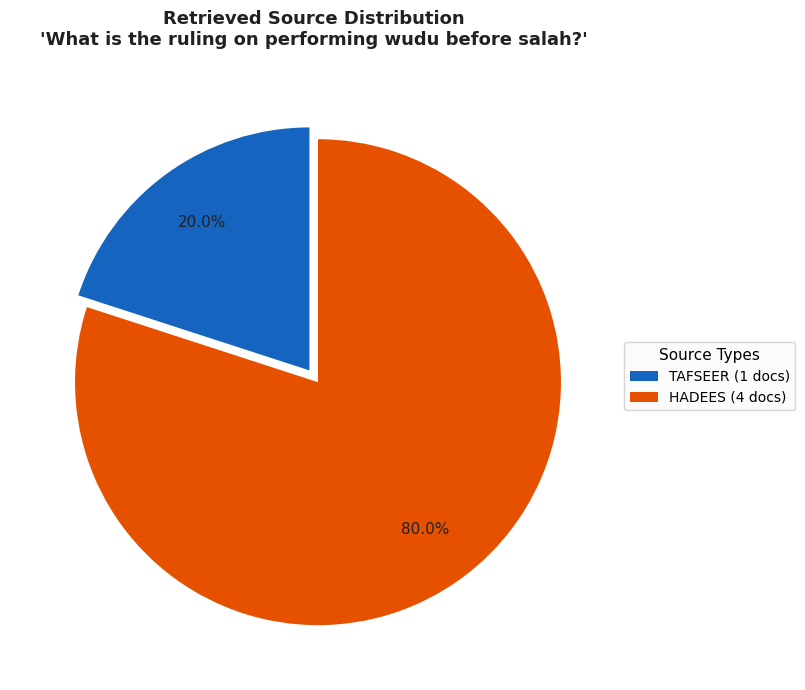

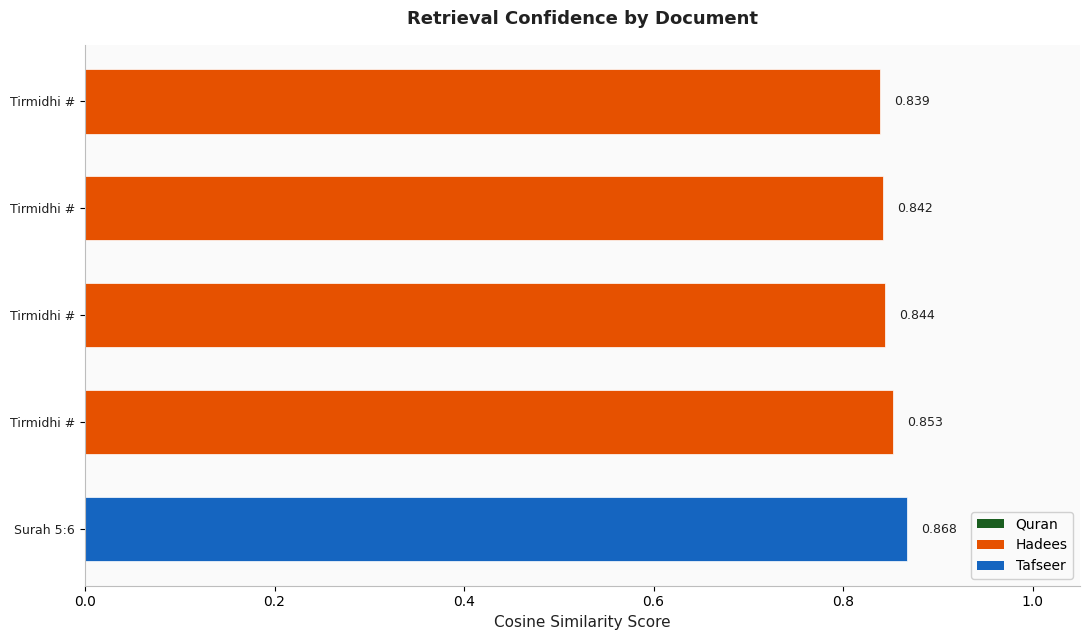

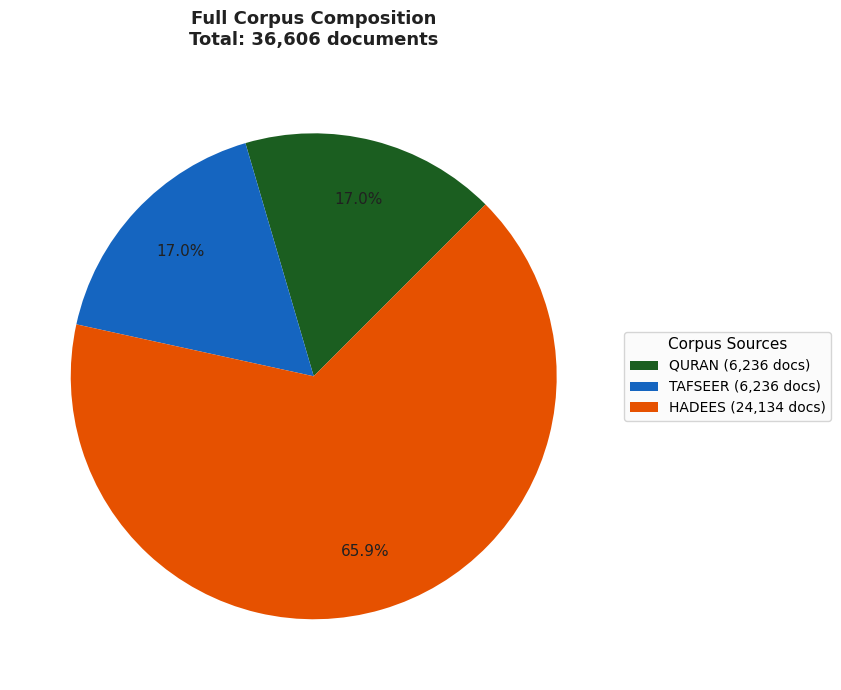

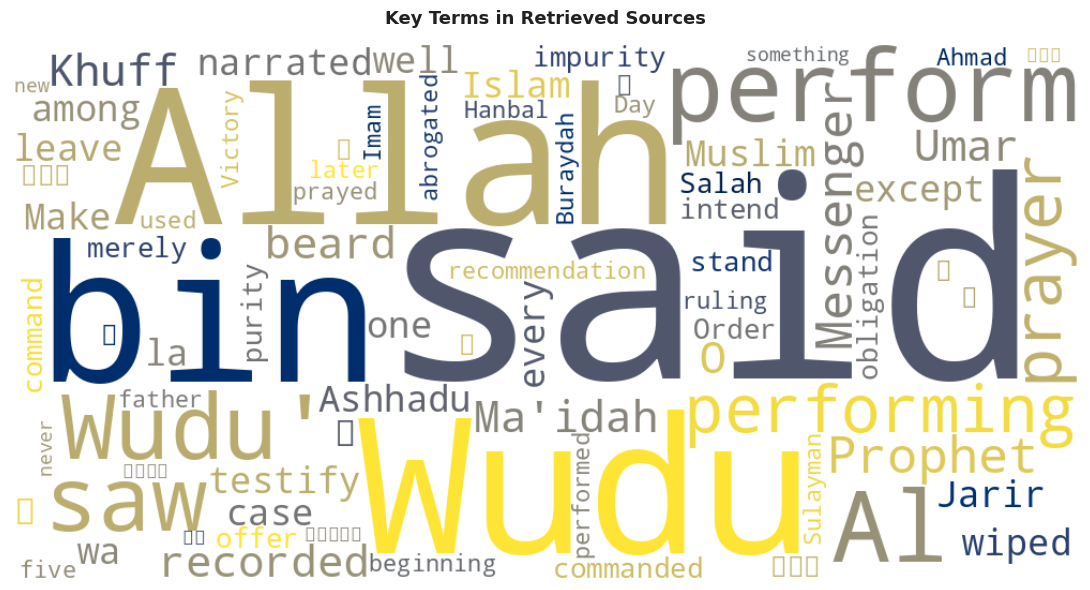


RETRIEVAL STATISTICS
Query: What is the ruling on performing wudu before salah?
Total sources retrieved: 5
Average similarity score: 0.8489
Highest score: 0.8677
Lowest score: 0.8385

Source breakdown:
  HADEES  : 4 docs ( 80.0%)
  TAFSEER : 1 docs ( 20.0%)


In [ ]:
!pip install -q matplotlib wordcloud

import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
import json

# Professional color palette
COLORS = {
    'quran': '#1B5E20',      # Deep green
    'hadees': '#E65100',      # Burnt orange
    'tafseer': '#1565C0',     # Professional blue
    'background': '#FAFAFA',  # Light gray background
    'text': '#212121'         # Dark text
}

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.facecolor'] = COLORS['background']
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#BDBDBD'
plt.rcParams['axes.linewidth'] = 0.8

# Test question
test_question = "What is the ruling on performing wudu before salah?"
result = ask_fiqah(test_question, top_k=5)

# ── 1. Source Distribution Pie Chart with Legend ─────────────────────────────
source_types = [doc['type'] for doc in result['sources']]
type_counts = {}
for t in source_types:
    type_counts[t] = type_counts.get(t, 0) + 1

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    type_counts.values(),
    labels=None,
    autopct='%1.1f%%',
    colors=[COLORS.get(k, '#757575') for k in type_counts.keys()],
    startangle=90,
    explode=[0.03] * len(type_counts),
    pctdistance=0.75,
    textprops={'fontsize': 11, 'color': COLORS['text']}
)

# Add legend
legend_labels = [f"{k.upper()} ({v} docs)" for k, v in type_counts.items()]
ax.legend(wedges, legend_labels, title="Source Types", loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10, title_fontsize=11)

ax.set_title(f"Retrieved Source Distribution\n'{test_question}'",
             fontsize=13, color=COLORS['text'], pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FiqahQA/source_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 2. Similarity Score Horizontal Bar Chart with Legend ─────────────────────
fig, ax = plt.subplots(figsize=(11, 6.5))

references = []
for doc in result['sources']:
    ref = doc['reference']
    if len(ref) > 45:
        ref = ref[:42] + '...'
    references.append(ref)

scores = [doc['score'] for doc in result['sources']]
bar_colors = [COLORS.get(doc['type'], '#757575') for doc in result['sources']]

bars = ax.barh(range(len(references)), scores, color=bar_colors, height=0.6, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(references)))
ax.set_yticklabels(references, fontsize=9, color=COLORS['text'])
ax.set_xlabel('Cosine Similarity Score', fontsize=11, color=COLORS['text'])
ax.set_title('Retrieval Confidence by Document', fontsize=13, color=COLORS['text'], pad=15, fontweight='bold')
ax.set_xlim(0, 1.05)

# Add score labels
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax.text(score + 0.015, i, f'{score:.3f}', va='center', fontsize=9, color=COLORS['text'])

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['quran'], label='Quran'),
                   Patch(facecolor=COLORS['hadees'], label='Hadees'),
                   Patch(facecolor=COLORS['tafseer'], label='Tafseer')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FiqahQA/similarity_scores.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 3. Overall Corpus Composition with Legend ────────────────────────────────
with open('/content/drive/MyDrive/FiqahQA/data/corpus.json', 'r', encoding='utf-8') as f:
    corpus = json.load(f)

corpus_types = {}
for doc in corpus:
    t = doc['type']
    corpus_types[t] = corpus_types.get(t, 0) + 1

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    corpus_types.values(),
    labels=None,
    autopct='%1.1f%%',
    colors=[COLORS.get(k, '#757575') for k in corpus_types.keys()],
    startangle=45,
    pctdistance=0.75,
    textprops={'fontsize': 11, 'color': COLORS['text']}
)

legend_labels = [f"{k.upper()} ({v:,} docs)" for k, v in corpus_types.items()]
ax.legend(wedges, legend_labels, title="Corpus Sources", loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10, title_fontsize=11)

ax.set_title(f"Full Corpus Composition\nTotal: {len(corpus):,} documents",
             fontsize=13, color=COLORS['text'], pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FiqahQA/corpus_composition.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 4. Word Cloud ────────────────────────────────────────────────────────────
all_retrieved_text = " ".join([doc['text'] for doc in result['sources']])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='cividis',
    max_words=80,
    contour_width=0.5,
    contour_color='#BDBDBD'
).generate(all_retrieved_text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Key Terms in Retrieved Sources', fontsize=13, color=COLORS['text'], pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/FiqahQA/wordcloud.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 5. Summary Statistics ────────────────────────────────────────────────────
print("\n" + "="*60)
print("RETRIEVAL STATISTICS")
print("="*60)
print(f"Query: {test_question}")
print(f"Total sources retrieved: {len(result['sources'])}")
print(f"Average similarity score: {np.mean(scores):.4f}")
print(f"Highest score: {max(scores):.4f}")
print(f"Lowest score: {min(scores):.4f}")
print("\nSource breakdown:")
for t, count in sorted(type_counts.items()):
    pct = count / len(result['sources']) * 100
    print(f"  {t.upper():8s}: {count} docs ({pct:5.1f}%)")

In [ ]:
import shutil
import os

BASE_DIR = '/content/drive/MyDrive/FiqahQA'

# Create a zip of the data folder
shutil.make_archive('/content/fiqah_qa_data', 'zip', BASE_DIR)

print("Data exported. Download the file from the Files panel on the left.")
print("File: /content/fiqah_qa_data.zip")

Data exported. Download the file from the Files panel on the left.
File: /content/fiqah_qa_data.zip
